In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('traffic.csv')

In [3]:
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [4]:
df.shape

(48120, 4)

In [5]:
df = df.drop_duplicates()

In [6]:
df.shape

(48120, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [8]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [9]:
df['Hour'] = df['DateTime'].dt.hour

In [10]:
df.head()

,DateTime,Junction,Vehicles,ID,Hour
0,2015-11-01 00:00:00,1,15,20151101001,0
1,2015-11-01 01:00:00,1,13,20151101011,1
2,2015-11-01 02:00:00,1,10,20151101021,2
3,2015-11-01 03:00:00,1,7,20151101031,3
4,2015-11-01 04:00:00,1,9,20151101041,4


In [11]:
hourly_avg = df.groupby('Hour')['Vehicles'].mean().reset_index()
hourly_avg

,Hour,Vehicles
0,0,23.540648
1,1,19.654863
2,2,17.102743
3,3,14.847382
4,4,12.973067
5,5,12.173566
6,6,12.980050
7,7,14.703242
8,8,16.402993
9,9,19.379551


In [12]:
df['Junction'].unique()

array([1, 2, 3, 4])

In [13]:
X = df.drop(['DateTime','ID','Vehicles'],axis=1)
y = df['Vehicles']

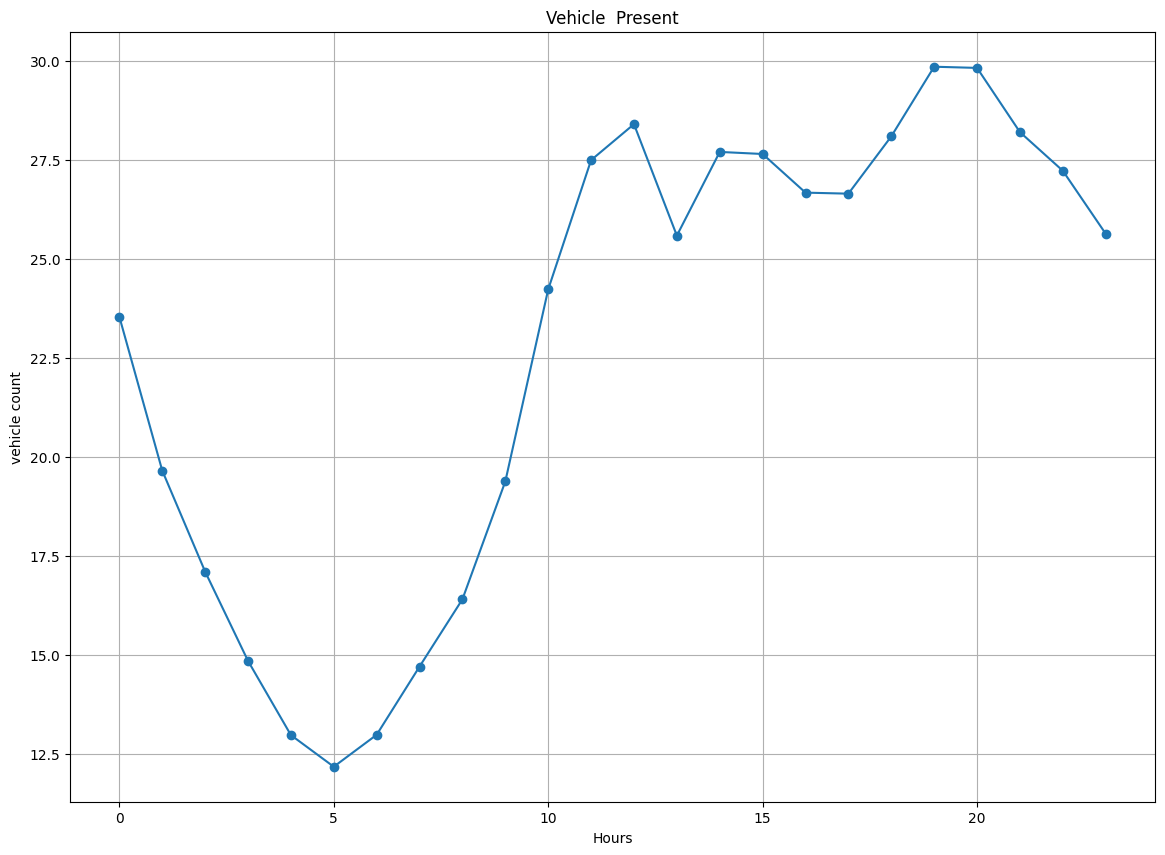

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
plt.plot(hourly_avg['Hour'], hourly_avg['Vehicles'], marker='o')
plt.xlabel('Hours')
plt.ylabel('vehicle count')
plt.title('Vehicle  Present')
plt.grid()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)

In [17]:
X_train_scale.shape

(33684, 2)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scale,y_train)
y_pred = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))
print('--test--')
print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


train
15.878804514495632
252.13643280956686
11.62226342514946
0.42392786171385644
--test--
15.38875207336732
236.81369037556695
11.36101420743164
0.427843596679496


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train_scale,y_train)
y_pred = rf.predict(X_test_scale)
y_pred_train = rf.predict(X_train_scale)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))
print('--test--')
print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


train
12.7402046250455
162.31281388803075
8.344214079725777
0.6291535946400091
--test--
12.527863995903207
156.94737629984786
8.287123247881526
0.6208055108980493


In [20]:
from xgboost import XGBRFRegressor

xg = XGBRFRegressor()
xg.fit(X_train_scale,y_train)
y_pred = xg.predict(X_test_scale)
y_pred_train = xg.predict(X_train_scale)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))
print('--test--')
print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


train
12.967679023742676
168.16070556640625
8.508369445800781
0.6157925128936768
--test--
12.660893440246582
160.2982177734375
8.406932830810547
0.6127097010612488


In [22]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_train_scale,y_train)
y_pred = knn.predict(X_test_scale)
y_pred_train = knn.predict(X_train_scale)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))
print('--test--')
print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


train
14.322089847506456
205.1222576000475
9.287718204488778
0.5313441368666141
--test--
14.147339176336182
200.1472057702965
9.214169437517318
0.5164320727971026


In [23]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train_scale,y_train)
y_pred = svr.predict(X_test_scale)
y_pred_train = svr.predict(X_train_scale)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))
print('--test--')
print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


train
13.10464154789083
171.73163009870657
8.307147923870982
0.6076338264171189
--test--
12.757344269372629
162.74983280729467
8.212731777273321
0.6067864200234494
